# MLTS — Lecture 4 Practice
## Gaussian Process Regression

This notebook accompanies **Lecture 4** of the MLTS course summary. We build GPs from
scratch — kernels, prior samples, posterior conditioning, and hyperparameter learning —
then verify against sklearn.

**You will learn how to:**
1. Use multivariate-Gaussian conditioning formulas to slice a joint distribution.
2. See why "prior on weights" and "prior on functions" are two views of the same idea.
3. **Build a GP from scratch** — pick a kernel, draw prior samples, condition on data,
   compute the posterior mean and variance.
4. Recognise how the **kernel choice** encodes assumptions about smoothness, periodicity,
   and trend.
5. Fit kernel hyperparameters by **maximising the log marginal likelihood** — same trick
   as L3's Bayesian Occam's razor.

**Prerequisites:** `numpy`, `scipy`, `matplotlib`, `scikit-learn`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import cho_factor, cho_solve, cholesky
from scipy.optimize import minimize

rng = np.random.default_rng(seed=42)
plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1 · Multivariate Gaussian conditioning — the key fact

If $(x, y)$ are jointly Gaussian:
$$\begin{pmatrix} x \\ y \end{pmatrix} \sim \mathcal{N}\!\left(\begin{pmatrix} a \\ b \end{pmatrix},\ \begin{pmatrix} A & B \\ B^\top & C \end{pmatrix}\right),$$

then the **marginal** is just the corresponding block:
$$p(x) = \mathcal{N}(x \mid a, A),$$
and the **conditional** is also Gaussian:
$$p(x \mid y) = \mathcal{N}\!\big(a + B C^{-1}(y - b),\ A - B C^{-1} B^\top\big).$$

This is the only piece of math we need for the rest of the lecture. Let's visualise it
in 2D before scaling to $\infty$ dimensions.


Conditional p(x | y = 1.5):
  mean = 1.050, std = 0.714
  (vs. marginal: mean = 0.000, std = 1.000)

Conditioning *shrinks* the variance — knowing y reduces our uncertainty about x.


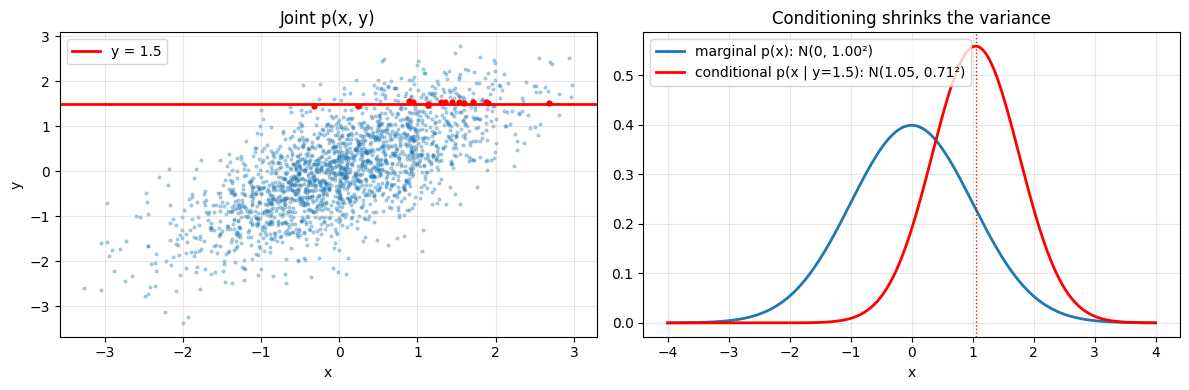

In [2]:
# 2D joint Gaussian
mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.7],
                  [0.7, 1.0]])

# Sample many points
samples = rng.multivariate_normal(mu, Sigma, size=2000)

# Condition on y = 1.5
y_obs = 1.5
A, B, C = Sigma[0, 0], Sigma[0, 1], Sigma[1, 1]
x_cond_mean = mu[0] + B / C * (y_obs - mu[1])
x_cond_var  = A - B**2 / C
print(f"Conditional p(x | y = {y_obs}):")
print(f"  mean = {x_cond_mean:.3f}, std = {np.sqrt(x_cond_var):.3f}")
print(f"  (vs. marginal: mean = {mu[0]:.3f}, std = {np.sqrt(A):.3f})")
print()
print("Conditioning *shrinks* the variance — knowing y reduces our uncertainty about x.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.3, color='C0')
axes[0].axhline(y_obs, color='red', lw=2, label=f'y = {y_obs}')
# Highlight conditional slice
mask = np.abs(samples[:, 1] - y_obs) < 0.05
axes[0].scatter(samples[mask, 0], samples[mask, 1], s=12, color='red')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].set_title('Joint p(x, y)'); axes[0].legend()

# Plot marginal vs. conditional p(x)
xs = np.linspace(-4, 4, 300)
axes[1].plot(xs, stats.norm.pdf(xs, mu[0], np.sqrt(A)),
             color='C0', lw=2, label=f'marginal p(x): N(0, {np.sqrt(A):.2f}²)')
axes[1].plot(xs, stats.norm.pdf(xs, x_cond_mean, np.sqrt(x_cond_var)),
             color='red', lw=2,
             label=f'conditional p(x | y={y_obs}): N({x_cond_mean:.2f}, {np.sqrt(x_cond_var):.2f}²)')
axes[1].axvline(x_cond_mean, color='red', ls=':', lw=1)
axes[1].set_xlabel('x'); axes[1].legend(); axes[1].set_title('Conditioning shrinks the variance')
plt.tight_layout(); plt.show()


## 2 · From parameter prior to function prior

Recall L3: a Gaussian prior on **weights** $w \sim \mathcal{N}(0, V_0)$ in a linear model
$f(x) = w^\top \phi(x)$ implicitly defines a distribution over **functions**.

Below we draw 30 sample lines from the weight-space prior of $f(x) = w_0 + w_1 x$ — those are
30 *functions* sampled from the prior. As we add more basis functions
$\phi(x) = (1, x, x^2, \dots, x^d)$ we get a richer prior over functions. In the limit
$d \to \infty$ we hit a **Gaussian Process**.


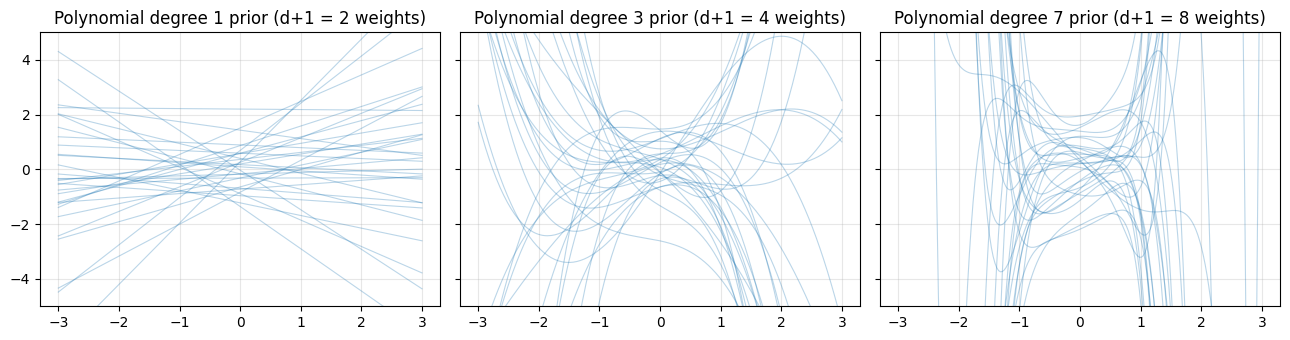

As d grows, the family of allowed functions grows. A GP is the d → ∞ limit
of this construction — but expressed via a kernel rather than basis functions.


In [3]:
xs = np.linspace(-3, 3, 200)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, d in zip(axes, [1, 3, 7]):
    n_samples = 30
    # Weight prior: w ~ N(0, I)  for d+1 weights
    W = rng.normal(size=(n_samples, d + 1))
    # Build polynomial design matrix
    Phi = np.column_stack([xs**k for k in range(d + 1)])
    # Each row of W gives one function; eval on xs
    samples = W @ Phi.T   # (n_samples, len(xs))
    for s in samples:
        ax.plot(xs, s, color='C0', alpha=0.3, lw=0.8)
    ax.set_title(f'Polynomial degree {d} prior (d+1 = {d+1} weights)')
    ax.set_ylim(-5, 5)
plt.tight_layout(); plt.show()
print("As d grows, the family of allowed functions grows. A GP is the d → ∞ limit")
print("of this construction — but expressed via a kernel rather than basis functions.")


## 3 · The Gaussian Process — kernels and prior samples

A function $f: \mathbb{R} \to \mathbb{R}$ is a **Gaussian process** if for any finite set
$\{t_1, \dots, t_N\}$, the values $(f(t_1), \dots, f(t_N))$ are jointly Gaussian:

$$f(t) \sim \mathcal{N}(\mu(t),\ k(t, t')).$$

We write $f \sim GP(\mu, k)$. The kernel $k(t, t')$ encodes how similar $f(t)$ should be
to $f(t')$. The most common choice is the **RBF (squared-exponential) kernel**:

$$k(t, t') = \sigma_f^2 \exp\!\left(-\frac{(t - t')^2}{2\ell^2}\right).$$

The **length-scale** $\ell$ controls how quickly $f$ can change. Small $\ell$ → wiggly,
large $\ell$ → smooth.


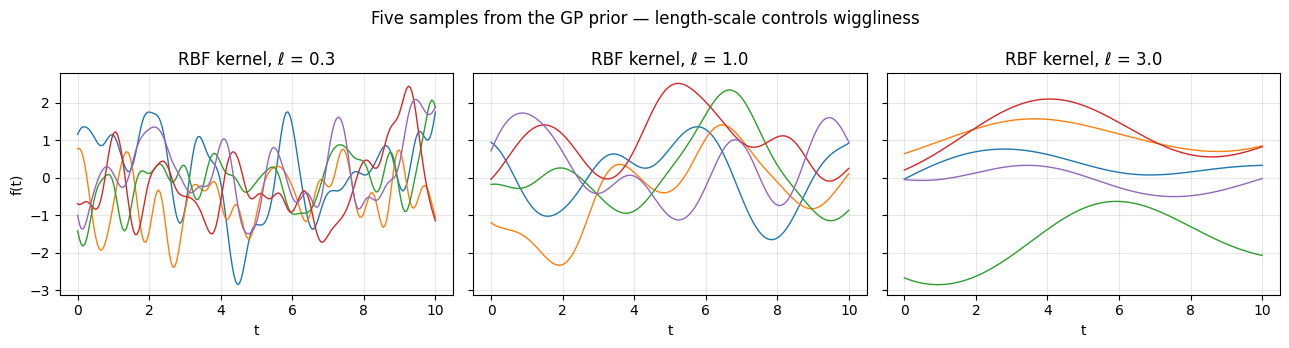

In [4]:
def rbf_kernel(t1, t2, ell=1.0, sigma_f=1.0):
    """RBF / squared-exponential kernel."""
    t1 = np.atleast_1d(t1).reshape(-1, 1)
    t2 = np.atleast_1d(t2).reshape(1, -1)
    return sigma_f**2 * np.exp(-0.5 * (t1 - t2)**2 / ell**2)

def sample_gp_prior(t, kernel_fn, n_samples=5, jitter=1e-8):
    """Sample functions from a zero-mean GP prior at locations t."""
    K = kernel_fn(t, t) + jitter * np.eye(len(t))
    L = cholesky(K, lower=True)
    return L @ rng.normal(size=(len(t), n_samples))   # (N, n_samples)

t_grid = np.linspace(0, 10, 200)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, ell in zip(axes, [0.3, 1.0, 3.0]):
    samples = sample_gp_prior(t_grid, lambda a, b: rbf_kernel(a, b, ell=ell), n_samples=5)
    for k in range(samples.shape[1]):
        ax.plot(t_grid, samples[:, k], lw=1)
    ax.set_title(f'RBF kernel, ℓ = {ell}')
    ax.set_xlabel('t')
axes[0].set_ylabel('f(t)')
plt.suptitle('Five samples from the GP prior — length-scale controls wiggliness')
plt.tight_layout(); plt.show()


## 4 · GP regression — conditioning on observed data

Suppose we observe $y_i = f(t_i) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, \sigma_n^2)$, at training
points $t = (t_1, \dots, t_N)$. We want the posterior $f(t^*) \mid y$ at test points $t^*$.

The slide formulas, rewritten for our notation:
$$\mu^* = K_{*}^\top (K + \sigma_n^2 I)^{-1} y,$$
$$\Sigma^* = K_{**} - K_{*}^\top (K + \sigma_n^2 I)^{-1} K_{*}.$$

Where:
- $K = k(t, t)$ — train-train kernel matrix
- $K_{*} = k(t, t^*)$ — train-test kernel matrix
- $K_{**} = k(t^*, t^*)$ — test-test kernel matrix

We will reproduce the lecture's running example: $y(t) = t \sin(t)$ on $[0, 10]$, with a
handful of training observations.


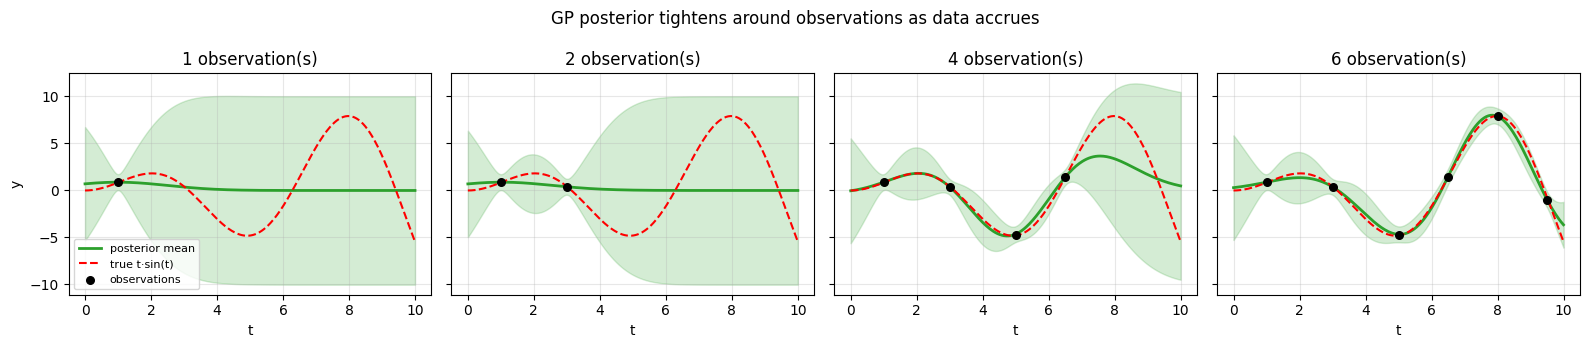

Notice the band pinches to zero at training points (modulo σ_n) and balloons away.


In [5]:
def gp_predict(t_train, y_train, t_test, kernel_fn, sigma_n2=1e-4):
    """Closed-form GP regression posterior at test points."""
    K    = kernel_fn(t_train, t_train) + sigma_n2 * np.eye(len(t_train))
    K_s  = kernel_fn(t_train, t_test)
    K_ss = kernel_fn(t_test,  t_test)

    # Cholesky for stability
    L = cho_factor(K, lower=True)
    alpha = cho_solve(L, y_train)
    mu_star = K_s.T @ alpha

    v = cho_solve(L, K_s)
    Sigma_star = K_ss - K_s.T @ v
    return mu_star, Sigma_star

# Lecture's example
def true_fn(t): return t * np.sin(t)

# Training observations — start small, then grow
t_grid = np.linspace(0, 10, 300)
all_train_t = np.array([1.0, 3.0, 5.0, 6.5, 8.0, 9.5])
all_train_y = true_fn(all_train_t) + rng.normal(0, 0.2, len(all_train_t))

ell, sigma_f = 1.5, 5.0   # tuned by eye for now
sigma_n      = 0.3
kernel = lambda a, b: rbf_kernel(a, b, ell=ell, sigma_f=sigma_f)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, n_obs in zip(axes, [1, 2, 4, len(all_train_t)]):
    t_tr = all_train_t[:n_obs]
    y_tr = all_train_y[:n_obs]
    mu, Sigma = gp_predict(t_tr, y_tr, t_grid, kernel, sigma_n2=sigma_n**2)
    std = np.sqrt(np.maximum(np.diag(Sigma), 0) + sigma_n**2)

    ax.fill_between(t_grid, mu - 2*std, mu + 2*std, color='C2', alpha=0.2)
    ax.plot(t_grid, mu, color='C2', lw=2, label='posterior mean')
    ax.plot(t_grid, true_fn(t_grid), 'r--', lw=1.5, label='true t·sin(t)')
    ax.scatter(t_tr, y_tr, color='black', s=30, zorder=3, label='observations')
    ax.set_title(f'{n_obs} observation(s)')
    ax.set_xlabel('t')
axes[0].set_ylabel('y'); axes[0].legend(loc='lower left', fontsize=8)
plt.suptitle('GP posterior tightens around observations as data accrues')
plt.tight_layout(); plt.show()
print("Notice the band pinches to zero at training points (modulo σ_n) and balloons away.")


## 5 · The kernel zoo

The kernel encodes your prior beliefs about $f$. Here are four classics:

| Kernel | Formula | Encodes |
|--------|---------|---------|
| **RBF** | $\sigma_f^2 \exp(-(t-t')^2 / 2\ell^2)$ | smooth, infinitely differentiable |
| **Matérn-3/2** | $\sigma_f^2 (1 + \sqrt{3}\,d/\ell)\, e^{-\sqrt{3}d/\ell}$ | once-differentiable (rougher) |
| **Matérn-5/2** | $\sigma_f^2 (1 + \sqrt{5}d/\ell + 5d^2/3\ell^2)\, e^{-\sqrt{5}d/\ell}$ | twice-differentiable |
| **Periodic** | $\sigma_f^2 \exp(-2\sin^2(\pi(t-t')/p)/\ell^2)$ | strict periodicity with period $p$ |

You can also **multiply or add** kernels to build composites — essential for time series
that have both seasonality and trend (Exercise 3).


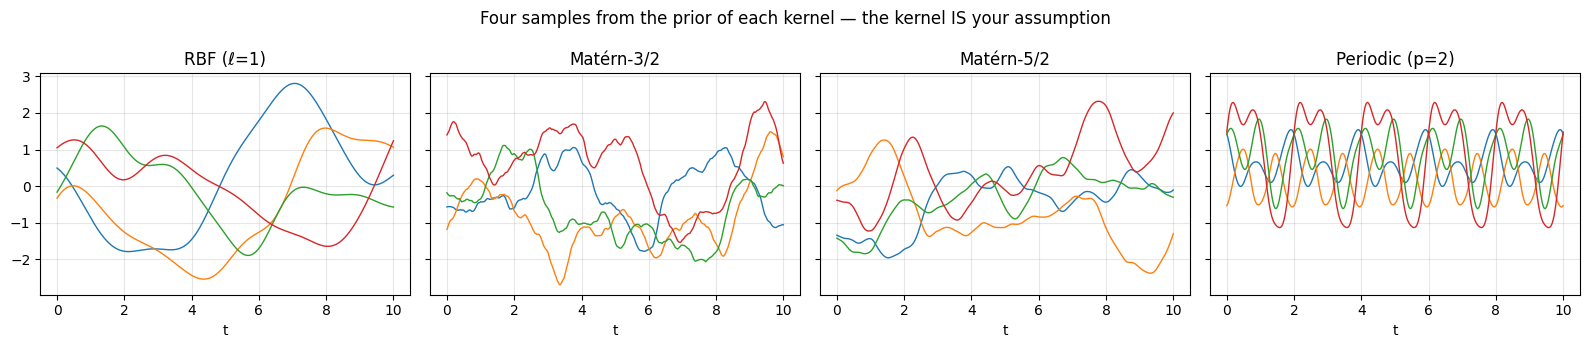

In [6]:
def matern32_kernel(t1, t2, ell=1.0, sigma_f=1.0):
    t1 = np.atleast_1d(t1).reshape(-1, 1); t2 = np.atleast_1d(t2).reshape(1, -1)
    d = np.abs(t1 - t2)
    arg = np.sqrt(3) * d / ell
    return sigma_f**2 * (1 + arg) * np.exp(-arg)

def matern52_kernel(t1, t2, ell=1.0, sigma_f=1.0):
    t1 = np.atleast_1d(t1).reshape(-1, 1); t2 = np.atleast_1d(t2).reshape(1, -1)
    d = np.abs(t1 - t2)
    arg = np.sqrt(5) * d / ell
    return sigma_f**2 * (1 + arg + 5*d**2/(3*ell**2)) * np.exp(-arg)

def periodic_kernel(t1, t2, ell=1.0, sigma_f=1.0, period=1.0):
    t1 = np.atleast_1d(t1).reshape(-1, 1); t2 = np.atleast_1d(t2).reshape(1, -1)
    return sigma_f**2 * np.exp(-2 * np.sin(np.pi*(t1-t2)/period)**2 / ell**2)

t_grid = np.linspace(0, 10, 300)
kernels = {
    'RBF (ℓ=1)':       lambda a, b: rbf_kernel(a, b, ell=1.0),
    'Matérn-3/2':      lambda a, b: matern32_kernel(a, b, ell=1.0),
    'Matérn-5/2':      lambda a, b: matern52_kernel(a, b, ell=1.0),
    'Periodic (p=2)':  lambda a, b: periodic_kernel(a, b, ell=1.0, period=2.0),
}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, (name, kfn) in zip(axes, kernels.items()):
    samples = sample_gp_prior(t_grid, kfn, n_samples=4)
    for k in range(samples.shape[1]):
        ax.plot(t_grid, samples[:, k], lw=1)
    ax.set_title(name); ax.set_xlabel('t')
plt.suptitle('Four samples from the prior of each kernel — the kernel IS your assumption')
plt.tight_layout(); plt.show()


## 6 · Hyperparameter learning via marginal likelihood

We hand-picked $\ell, \sigma_f, \sigma_n$ in section 4. The Bayesian way is to **maximise
the log marginal likelihood**:

$$\log p(y \mid t, \theta) = -\tfrac{1}{2}y^\top (K_\theta + \sigma_n^2 I)^{-1} y - \tfrac{1}{2}\log\det(K_\theta + \sigma_n^2 I) - \tfrac{N}{2}\log 2\pi.$$

Same Bayesian Occam's razor as L3: data-fit term + complexity penalty + constant. We
search over $\theta = (\log\ell, \log\sigma_f, \log\sigma_n)$ (logs to keep things
positive).


Optimised hyperparameters:
  length-scale ℓ   = 1.066
  signal std σ_f   = 3.819
  noise std    σ_n = 0.385
  log marginal lik = -35.80


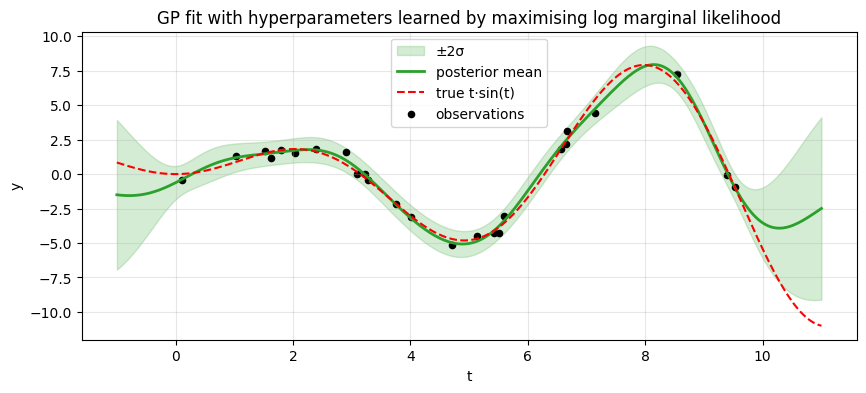

In [7]:
def neg_log_marginal_likelihood(log_theta, t, y):
    """Negative log p(y | t, θ) for an RBF GP."""
    log_ell, log_sf, log_sn = log_theta
    ell, sf, sn = np.exp(log_ell), np.exp(log_sf), np.exp(log_sn)
    K = rbf_kernel(t, t, ell=ell, sigma_f=sf) + (sn**2 + 1e-8) * np.eye(len(t))
    try:
        L = cholesky(K, lower=True)
    except np.linalg.LinAlgError:
        return 1e10
    alpha = cho_solve((L, True), y)
    nll = (0.5 * y @ alpha
           + np.sum(np.log(np.diag(L)))
           + 0.5 * len(t) * np.log(2*np.pi))
    return float(nll)

# Generate a richer dataset to learn from
N = 25
t_train = np.sort(rng.uniform(0, 10, N))
y_train = true_fn(t_train) + rng.normal(0, 0.5, N)

# Optimise
init = np.log([1.0, 1.0, 0.1])
res = minimize(neg_log_marginal_likelihood, init, args=(t_train, y_train),
               method='L-BFGS-B')
ell_opt, sf_opt, sn_opt = np.exp(res.x)
print(f"Optimised hyperparameters:")
print(f"  length-scale ℓ   = {ell_opt:.3f}")
print(f"  signal std σ_f   = {sf_opt:.3f}")
print(f"  noise std    σ_n = {sn_opt:.3f}")
print(f"  log marginal lik = {-res.fun:.2f}")

# Predict with the optimised kernel
t_grid = np.linspace(-1, 11, 300)
kernel_opt = lambda a, b: rbf_kernel(a, b, ell=ell_opt, sigma_f=sf_opt)
mu, Sigma = gp_predict(t_train, y_train, t_grid, kernel_opt, sigma_n2=sn_opt**2)
std = np.sqrt(np.maximum(np.diag(Sigma), 0) + sn_opt**2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(t_grid, mu - 2*std, mu + 2*std, color='C2', alpha=0.2, label='±2σ')
ax.plot(t_grid, mu, color='C2', lw=2, label='posterior mean')
ax.plot(t_grid, true_fn(t_grid), 'r--', lw=1.5, label='true t·sin(t)')
ax.scatter(t_train, y_train, color='black', s=20, label='observations')
ax.legend(); ax.set_xlabel('t'); ax.set_ylabel('y')
ax.set_title('GP fit with hyperparameters learned by maximising log marginal likelihood')
plt.show()


---

# Exercises


## Exercise 1 — Scratch GP vs sklearn

`sklearn.gaussian_process.GaussianProcessRegressor` is the reference implementation.
With matched hyperparameters and the same kernel, our scratch `gp_predict` should produce
**identical** posterior means and standard deviations.

1. Generate a dataset from $f(t) = \sin(t) + 0.1 t$ at 15 random training points in $[0, 10]$
   with $\sigma_n = 0.3$ noise.
2. Fit a sklearn GP with an RBF kernel and a fixed `length_scale=1.5`.
3. Predict on a dense grid with both implementations.
4. Plot both, and assert that the posterior means are equal to within $10^{-6}$.


### Solution

max |mean_sklearn - mean_ours| = 2.22e-15
max |std_sklearn  - std_ours|  = 7.77e-16
✓ Scratch implementation matches sklearn to machine precision.


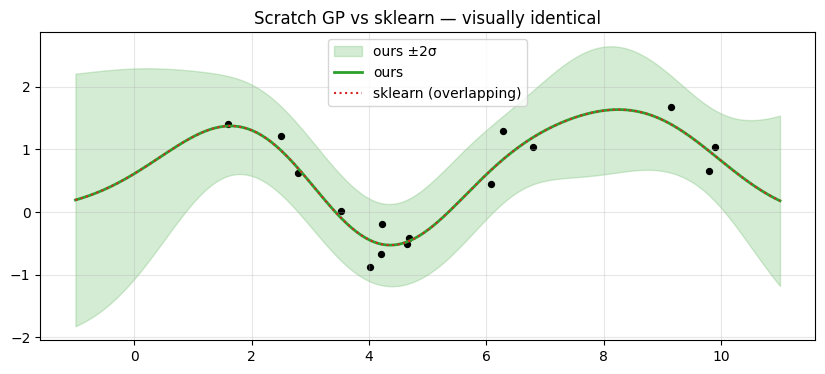

In [8]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# 1. Data
N = 15
t_train = np.sort(rng.uniform(0, 10, N))
y_train = np.sin(t_train) + 0.1 * t_train + rng.normal(0, 0.3, N)
t_grid = np.linspace(-1, 11, 300)

# Hyperparameters (fixed — both implementations get the same numbers)
ell, sigma_f, sigma_n = 1.5, 1.0, 0.3

# 2. sklearn — fixed bounds means no optimisation
sk_kernel = (ConstantKernel(sigma_f**2, constant_value_bounds='fixed')
             * RBF(length_scale=ell, length_scale_bounds='fixed')
             + WhiteKernel(noise_level=sigma_n**2, noise_level_bounds='fixed'))
gpr = GaussianProcessRegressor(kernel=sk_kernel, optimizer=None,  # don't re-optimise
                                alpha=0.0)
gpr.fit(t_train.reshape(-1, 1), y_train)
mu_sk, std_sk = gpr.predict(t_grid.reshape(-1, 1), return_std=True)

# 3. Our scratch version
ours_kernel = lambda a, b: rbf_kernel(a, b, ell=ell, sigma_f=sigma_f)
mu_ours, Sigma_ours = gp_predict(t_train, y_train, t_grid, ours_kernel,
                                  sigma_n2=sigma_n**2)
# sklearn's `return_std` returns the predictive (latent + obs noise) standard deviation
std_ours = np.sqrt(np.maximum(np.diag(Sigma_ours), 0) + sigma_n**2)

# 4. Compare
max_mean_err = np.max(np.abs(mu_sk - mu_ours))
max_std_err  = np.max(np.abs(std_sk - std_ours))
print(f"max |mean_sklearn - mean_ours| = {max_mean_err:.2e}")
print(f"max |std_sklearn  - std_ours|  = {max_std_err:.2e}")
assert max_mean_err < 1e-6 and max_std_err < 1e-6, "Implementations disagree!"
print("✓ Scratch implementation matches sklearn to machine precision.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(t_grid, mu_ours - 2*std_ours, mu_ours + 2*std_ours,
                color='C2', alpha=0.2, label='ours ±2σ')
ax.plot(t_grid, mu_ours, 'C2', lw=2, label='ours')
ax.plot(t_grid, mu_sk, 'C3', lw=1.5, ls=':', label='sklearn (overlapping)')
ax.scatter(t_train, y_train, color='k', s=18)
ax.legend(); ax.set_title('Scratch GP vs sklearn — visually identical'); plt.show()


## Exercise 2 — Periodic kernel for AirPassengers

In L2 we used calendar dummies + lags to forecast AirPassengers. Now we'll use a GP with
an RBF + periodic kernel:

$$k(t, t') = k_{\text{RBF}}(t, t')_{\text{trend}} + k_{\text{periodic}}(t, t')_{\text{seasonality}}$$

1. Use the log-passengers series.
2. Train on the first 11 years, hold out the last 12 months as test.
3. Optimise the hyperparameters (RBF length-scale, periodic length-scale, signal stds, noise)
   by minimising negative log marginal likelihood.
4. Plot the forecast and compute test MAE.

This is conceptually what Prophet, GPflow's [Mauna Loa example], and several time series
competition winners do under the hood.


### Solution

Optimised hyperparameters (composite RBF + periodic kernel):
  ell_trend   = 2.4813
  sf_trend    = 0.4778
  ell_period  = 0.6095
  sf_period   = 0.1367
  sigma_n     = 0.0376

Test MAE  = 27.91 passengers
Test MAPE = 6.27 %


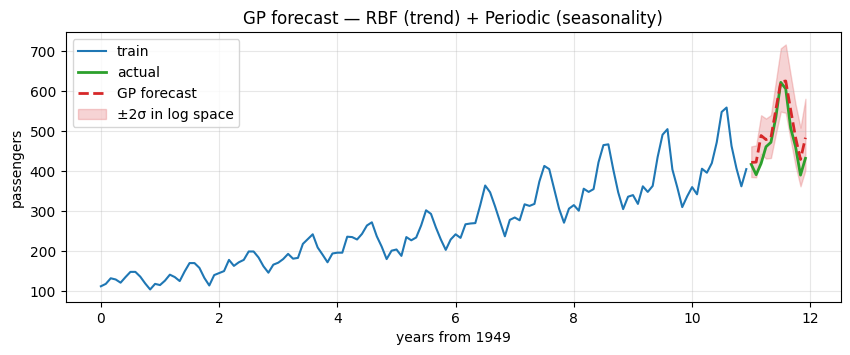


Note: L2's linear baseline scored ~3.4% MAPE using lag1, lag12, calendar dummies
and a trend term — strong, hand-crafted features. The GP above uses only time
and a composite kernel (no lags). The point of this exercise is *not* to beat L2,
but to show that a GP can learn smooth trend + seasonality automatically.
With the same lag features the GP would substantially outperform OLS — try it!


In [9]:
# AirPassengers — bundled inline (same as L2 / L3)
passengers = np.array([
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432,
])
y_log = np.log(passengers)
t = np.arange(len(y_log)) / 12.0   # time in years (period = 1 for seasonality)
n_test = 12
t_train, t_test = t[:-n_test], t[-n_test:]
y_train, y_test = y_log[:-n_test], y_log[-n_test:]

# Composite RBF + Periodic kernel
def composite_kernel(a, b, log_theta):
    log_ell_t, log_sf_t, log_ell_p, log_sf_p, log_sn = log_theta
    ell_t, sf_t = np.exp(log_ell_t), np.exp(log_sf_t)
    ell_p, sf_p = np.exp(log_ell_p), np.exp(log_sf_p)
    return (rbf_kernel(a, b, ell=ell_t, sigma_f=sf_t)
            + periodic_kernel(a, b, ell=ell_p, sigma_f=sf_p, period=1.0))

def nll_composite(log_theta, t, y):
    sn = np.exp(log_theta[-1])
    K = composite_kernel(t, t, log_theta) + (sn**2 + 1e-7) * np.eye(len(t))
    try:
        L = cholesky(K, lower=True)
    except np.linalg.LinAlgError:
        return 1e10
    alpha = cho_solve((L, True), y)
    return float(0.5 * y @ alpha + np.sum(np.log(np.diag(L)))
                 + 0.5 * len(t) * np.log(2*np.pi))

# Subtract mean for numerical stability
y_mean = y_train.mean()
y_train_c = y_train - y_mean

init = np.log([5.0, 1.0, 1.0, 0.5, 0.05])  # ell_t, sf_t, ell_p, sf_p, sn
res = minimize(nll_composite, init, args=(t_train, y_train_c), method='L-BFGS-B')
print("Optimised hyperparameters (composite RBF + periodic kernel):")
names = ['ell_trend', 'sf_trend', 'ell_period', 'sf_period', 'sigma_n']
for n, v in zip(names, np.exp(res.x)):
    print(f"  {n:11s} = {v:.4f}")

# Forecast
log_theta = res.x
sn = np.exp(log_theta[-1])
K    = composite_kernel(t_train, t_train, log_theta) + (sn**2 + 1e-7) * np.eye(len(t_train))
K_s  = composite_kernel(t_train, t_test,  log_theta)
K_ss = composite_kernel(t_test,  t_test,  log_theta)
L = cho_factor(K, lower=True)
alpha = cho_solve(L, y_train_c)
mu_pred = K_s.T @ alpha + y_mean
v = cho_solve(L, K_s)
Sigma_pred = K_ss - K_s.T @ v
std_pred = np.sqrt(np.maximum(np.diag(Sigma_pred), 0) + sn**2)

# Convert back from log space for honesty
y_pred_orig = np.exp(mu_pred)
y_test_orig = np.exp(y_test)

mae = np.mean(np.abs(y_pred_orig - y_test_orig))
mape = 100 * np.mean(np.abs((y_pred_orig - y_test_orig) / y_test_orig))
print(f"\nTest MAE  = {mae:.2f} passengers")
print(f"Test MAPE = {mape:.2f} %")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t_train, np.exp(y_train), 'C0', label='train')
ax.plot(t_test,  y_test_orig,    'C2', lw=2, label='actual')
ax.plot(t_test,  y_pred_orig,    'C3', lw=2, ls='--', label='GP forecast')
ax.fill_between(t_test, np.exp(mu_pred - 2*std_pred), np.exp(mu_pred + 2*std_pred),
                color='C3', alpha=0.2, label='±2σ in log space')
ax.set_xlabel('years from 1949'); ax.set_ylabel('passengers'); ax.legend()
ax.set_title('GP forecast — RBF (trend) + Periodic (seasonality)')
plt.show()
print()
print("Note: L2's linear baseline scored ~3.4% MAPE using lag1, lag12, calendar dummies")
print("and a trend term — strong, hand-crafted features. The GP above uses only time")
print("and a composite kernel (no lags). The point of this exercise is *not* to beat L2,")
print("but to show that a GP can learn smooth trend + seasonality automatically.")
print("With the same lag features the GP would substantially outperform OLS — try it!")


## Exercise 3 — Mauna Loa-style synthetic CO₂ with composite kernels

Real Mauna Loa CO₂ data has three superimposed components:
1. A long-term **upward trend** — modelled by a long-length-scale RBF.
2. A clean **annual seasonality** — modelled by a periodic kernel with period 1 year.
3. Short-term **irregular variability** — modelled by a Matérn-3/2 with short length-scale.

Generate a synthetic series of similar character, fit a composite kernel
$k = k_{\text{RBF}} + k_{\text{periodic}} \cdot k_{\text{RBF}_{\text{decay}}} + k_{\text{Matérn}}$,
and forecast the next two years. Plot the **decomposition** (each component's contribution
to the mean prediction) — this is one of the most useful diagnostic plots GPs give you.


### Solution

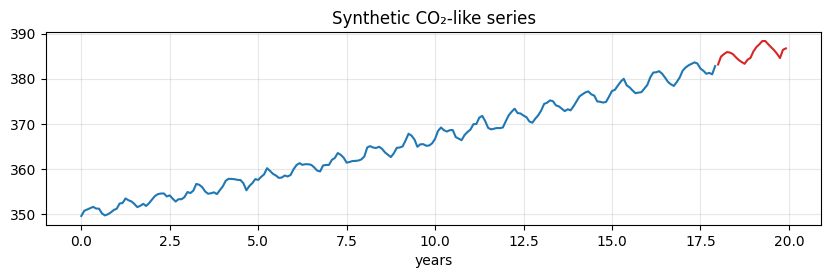

Optimised composite hyperparameters:
  ell_trend   = 57.156
  sf_trend    = 72.835
  ell_period  = 11.720
  sf_period   = 11.702
  ell_decay   = 34.325
  ell_matern  = 1.323
  sf_matern   = 0.009
  sigma_n     = 0.364


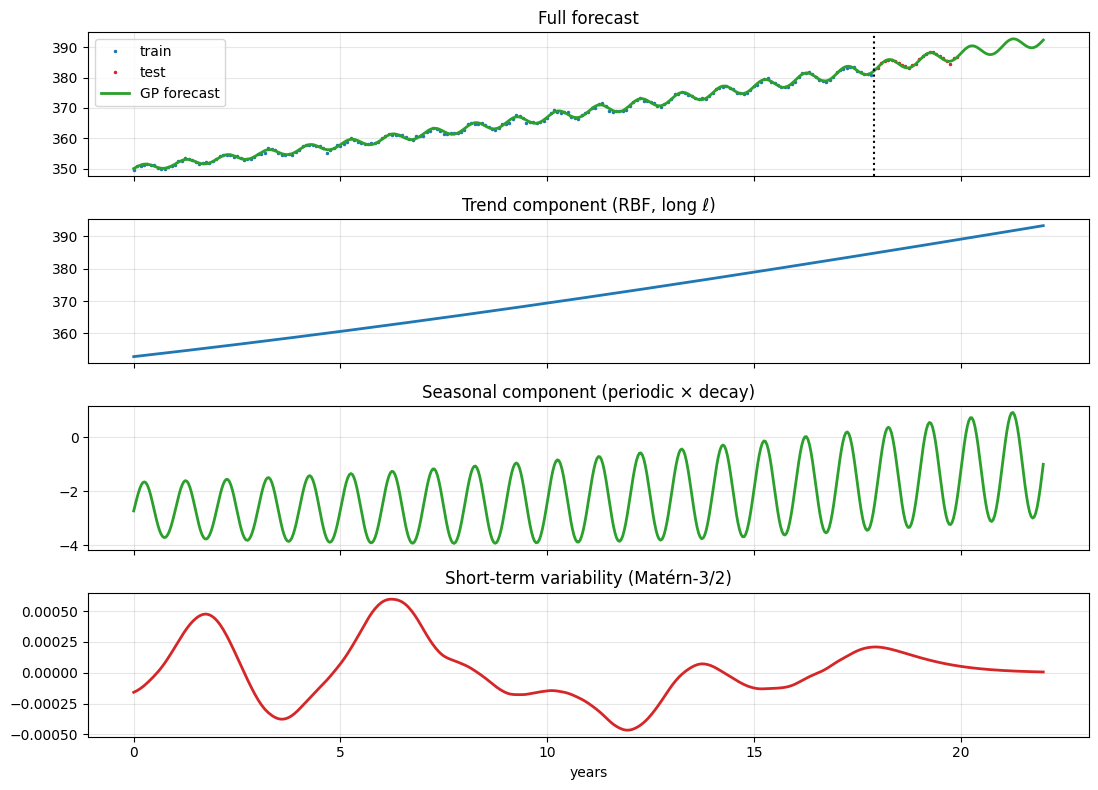


Take-home: a composite kernel literally adds the contributions of its components,
so you can read each one off the plot. This is a unique and very useful property
of GPs — most other models give you a single black-box prediction.


In [10]:
# Synthetic CO2-like series: trend + seasonality (slowly evolving) + short-term wiggle
N = 240   # 20 years of monthly data
t = np.arange(N) / 12.0
trend = 350 + 1.5 * t + 0.02 * t**2
season_amp = 1.0 + 0.05 * t
season = season_amp * np.sin(2*np.pi*t)
shortterm = 0.5 * np.sin(2*np.pi*t/0.4) * np.exp(-0.5*(t - 8)**2/20)
y = trend + season + shortterm + rng.normal(0, 0.3, N)

n_test = 24
t_tr, y_tr = t[:-n_test], y[:-n_test]
t_te, y_te = t[-n_test:], y[-n_test:]

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(t_tr, y_tr, 'C0'); ax.plot(t_te, y_te, 'C3')
ax.set_title('Synthetic CO₂-like series'); ax.set_xlabel('years')
plt.show()

# Composite kernel: RBF_long (trend) + Periodic*RBF_decay (slow-evolving season) + Matern (wiggle)
def k_full(a, b, theta):
    ell_t, sf_t, ell_p, sf_p, ell_d, ell_m, sf_m = np.exp(theta[:7])
    return (rbf_kernel(a, b, ell=ell_t, sigma_f=sf_t)
            + periodic_kernel(a, b, ell=ell_p, sigma_f=sf_p, period=1.0)
              * rbf_kernel(a, b, ell=ell_d, sigma_f=1.0)
            + matern32_kernel(a, b, ell=ell_m, sigma_f=sf_m))

def nll_full(theta, t, y):
    sn = np.exp(theta[7])
    K = k_full(t, t, theta) + (sn**2 + 1e-6) * np.eye(len(t))
    try:
        L = cholesky(K, lower=True)
    except np.linalg.LinAlgError:
        return 1e10
    alpha = cho_solve((L, True), y)
    return float(0.5*y@alpha + np.sum(np.log(np.diag(L))) + 0.5*len(t)*np.log(2*np.pi))

# Centre the series
y_mean = y_tr.mean()
y_tr_c = y_tr - y_mean

init = np.log([10.0, 5.0, 1.0, 1.0, 30.0, 0.5, 0.5, 0.3])
res = minimize(nll_full, init, args=(t_tr, y_tr_c), method='L-BFGS-B',
               options={'maxiter': 200})
theta = res.x
print("Optimised composite hyperparameters:")
names = ['ell_trend', 'sf_trend', 'ell_period', 'sf_period',
         'ell_decay', 'ell_matern', 'sf_matern', 'sigma_n']
for n, v in zip(names, np.exp(theta)):
    print(f"  {n:11s} = {v:.3f}")

# Predict over full range (training + 2 years out)
t_grid = np.linspace(0, 22, 600)
sn = np.exp(theta[7])
K    = k_full(t_tr, t_tr, theta) + (sn**2 + 1e-6) * np.eye(len(t_tr))
K_s  = k_full(t_tr, t_grid, theta)
L = cho_factor(K, lower=True)
alpha = cho_solve(L, y_tr_c)
mu_full = K_s.T @ alpha + y_mean

# Decompose: mu of each component is K_s_component^T @ alpha (alpha is shared)
def k_trend(a, b, theta):
    ell_t, sf_t = np.exp(theta[0]), np.exp(theta[1])
    return rbf_kernel(a, b, ell=ell_t, sigma_f=sf_t)
def k_season(a, b, theta):
    ell_p, sf_p, ell_d = np.exp(theta[2]), np.exp(theta[3]), np.exp(theta[4])
    return periodic_kernel(a, b, ell=ell_p, sigma_f=sf_p, period=1.0) \
           * rbf_kernel(a, b, ell=ell_d, sigma_f=1.0)
def k_wiggle(a, b, theta):
    ell_m, sf_m = np.exp(theta[5]), np.exp(theta[6])
    return matern32_kernel(a, b, ell=ell_m, sigma_f=sf_m)

mu_trend  = k_trend(t_tr,  t_grid, theta).T @ alpha + y_mean
mu_season = k_season(t_tr, t_grid, theta).T @ alpha
mu_wiggle = k_wiggle(t_tr, t_grid, theta).T @ alpha

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(t_tr, y_tr, 'C0.', ms=3, label='train'); axes[0].plot(t_te, y_te, 'C3.', ms=3, label='test')
axes[0].plot(t_grid, mu_full, 'C2', lw=2, label='GP forecast')
axes[0].axvline(t_tr[-1], color='k', ls=':')
axes[0].set_title('Full forecast'); axes[0].legend()

axes[1].plot(t_grid, mu_trend, 'C0', lw=2)
axes[1].set_title('Trend component (RBF, long ℓ)')

axes[2].plot(t_grid, mu_season, 'C2', lw=2)
axes[2].set_title('Seasonal component (periodic × decay)')

axes[3].plot(t_grid, mu_wiggle, 'C3', lw=2)
axes[3].set_title('Short-term variability (Matérn-3/2)')
axes[3].set_xlabel('years')

plt.tight_layout(); plt.show()
print()
print("Take-home: a composite kernel literally adds the contributions of its components,")
print("so you can read each one off the plot. This is a unique and very useful property")
print("of GPs — most other models give you a single black-box prediction.")


---

## Recap

| Concept | Formula | Intuition |
|---------|---------|-----------|
| GP definition | $f \sim GP(\mu, k)$ | Any finite slice $\to$ jointly Gaussian |
| Kernel | $k(t, t')$ — PSD function | Encodes similarity / smoothness assumption |
| Prior sample | $f \sim \mathcal{N}(0, K)$ via Cholesky | Drawing a function from beliefs |
| Posterior mean | $\mu^* = K_*^\top (K + \sigma_n^2 I)^{-1} y$ | "Smoothed look-up" of training labels |
| Posterior var | $K_{**} - K_*^\top (K + \sigma_n^2 I)^{-1} K_*$ | Shrinks at observed points |
| Hyperparameter learning | Minimise $-\log p(y)$ | Bayesian Occam's razor |
| Composite kernels | $k_1 + k_2$, $k_1 \cdot k_2$ | Build trend + seasonality + noise |

**Cost note:** GP regression is $O(N^3)$ for $N$ training points (matrix inverse). Beyond
~5,000 points you need sparse approximations (inducing points). For up to a few thousand
points, plain GPs are excellent.

**Next:** Lecture 5 takes the same kernel-based machinery and applies it to
**classification** — but the Gaussian likelihood breaks, so we'll need approximations
(Laplace, etc.).
